# AI Project — Relief Route Scheduling

**Focus algorithms:** *Local Beam Search* and *Genetic Algorithm (GA)*  

---

## Scenario
After a major storm, an emergency office must deliver supplies to **M drop-off locations** (shelters, clinics, distribution points).

A single truck:
1. starts at the **warehouse / depot**
2. must visit **every location exactly once**
3. returns to the depot

This is a **route-ordering optimization** problem (TSP-like):

- A candidate solution is a **permutation** (an ordering) of the locations.
- The objective is to **minimize total travel time** (we model travel time as Euclidean distance).
### Connectivity assumption (important)
We assume the travel network is a **fully connected graph**: the truck can travel directly between **any pair** of points (depot and all locations). Travel cost is computed from their coordinates (Euclidean distance).

---

## Project structure (two phases)

### Phase 1 — Local Beam Search
You will:
1. start with **k** random routes (the “beam”),
2. repeatedly generate nearby routes (neighbors) by swapping two stops,
3. keep the **best k** routes each iteration.

**What you should observe:** a known failure mode:  
**loss of diversity / beam collapse** → many routes in the beam become very similar, so the algorithm behaves like several hill-climbers and can get stuck in a poor local optimum.

### Phase 2 — Genetic Algorithm (GA) as a fix
You will:
1. maintain a population of routes,
2. repeatedly apply **selection + crossover + mutation**,
3. show that GA can escape plateaus where beam search gets stuck.

You will also run a **variant study**:
- Crossover: **OX** (Order Crossover) and **PBX** (Partially Mapped Crossover)
- Mutation: **swap**, **inversion**, **scramble**
- Mutation rate: compare at least **pm = 0.02** vs **pm = 0.08**

---

## Deliverables
1. **Beam Search results** + evidence of plateau/diversity collapse (plot diversity trace).
2. **GA results** that improve on beam search for the same instance.
3. A **mini-study** comparing GA operator variants (OX/PBX × 3 mutation types × 2 mutation rates).
4. Short written answers (see **Report Questions** at the end).

---
---

## Student coding requirements (you must implement these TODO placeholders)

This notebook contains working reference code for most components so you can focus on experimentation and interpretation.  
However, **two parts are intentionally left as placeholders**. You must implement them:

1. **Tournament selection (TODO):** implement a tournament-based parent selection method and run the same GA study using both roulette-wheel and tournament selection.
2. **Custom mutation (TODO):** design and implement one new mutation operator (`your_custom_mutation`) and test its effect.

These sections are explicitly labeled in the notebook as:

- `# TODO (STUDENT): ...`
- `# PLACEHOLDER (STUDENT IMPLEMENTS THIS)`

You are expected to write code in those cells, then rerun the experiments and interpret results.


## Glossary (terms you must understand)
- **Permutation:** an ordering of all locations with no repeats (e.g., `[3, 0, 2, 1]`).
- **Neighbor:** a route produced by a small change to another route (here: swapping two positions).
- **Seed:** a number that makes randomness reproducible (same seed → same random results).
- **Evaluation:** one computation of route cost (distance of a route). We count evaluations to compare compute effort fairly.

## What you will measure (evaluation metrics)

For each algorithm/variant, record:

- **best_cost**: the lowest route cost found (lower is better)
- **evaluated**: how many candidate routes were scored (cost computed)
- **runtime_ms**: wall-clock runtime (milliseconds)
- **stability across seeds**: run multiple times with different random seeds and report **mean ± std** of best_cost

### Why multiple seeds?
Both Beam Search (because it starts from random routes) and GA (random selection/crossover/mutation) are stochastic.
Running multiple seeds makes your conclusions more reliable.

### Required minimum
- At least **10 seeds** per configuration
- At least **one clustered instance**

## Submission directives (read carefully)

Prepare a Jupyter Notebook using this notebook as a starting point and complete all sections as outlined.

- You may use **Google Colab** to develop your notebook and then download it as a **Jupyter Notebook (.ipynb)** file for submission.
- Before downloading/submitting, you must run **Run all** and confirm there are **no errors**.
- We will **not** rerun your notebook. Your submitted `.ipynb` must already contain:
  - all results (tables),
  - all plots/figures,
  - and your written answers.
- Ensure clarity and completeness in each section, including detailed explanations and well-commented code or pseudocode.
- Start early. Attempting to complete the project on the due date will be extremely challenging.
- Rename your file as `LastName_FirstName_26Spr_Prj1.ipynb`.
- Failure to follow these instructions will result in point deductions.

In [2]:
# Imports
# Beginner tip: these are standard libraries for randomness, time measurement, and math.
import random, time, math
from dataclasses import dataclass
from typing import List, Tuple, Dict, Callable

# Third-party scientific libraries (commonly used in AI/ML work)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make tables easier to read in notebooks
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Part A — Problem Instance Generator (provided)

We model locations as 2D coordinates:

- One **depot** point `(x, y)` (the warehouse)
- **M** delivery locations `(x, y)`

Travel time = Euclidean distance between points.

### Why clustered instances?
We intentionally generate **clustered** instances, which often have many deceptive local optima.
That makes it easier to see **beam collapse** and why GA can help.

Clustering means locations are generated around a few **cluster centers**:

- First, we pick a few random center points.
- Then we create many locations **near** those centers (with small random noise).

Result: locations form “groups” on the map rather than being spread evenly everywhere.
This often makes routing tricky because there are many reasonable local patterns (good routes inside clusters) but combining clusters well is harder.

In [3]:
# A Point is a pair (x, y)
Point = Tuple[float, float]

def euclid(a: Point, b: Point) -> float:
    """Euclidean distance between two points."""
    return math.hypot(a[0]-b[0], a[1]-b[1])

def make_clustered_instance(
    M: int = 24,
    clusters: int = 4,
    spread: float = 8.0,
    cluster_radius: float = 1.2,
    seed: int = 0
) -> Tuple[Point, List[Point]]:
    """
    Create a clustered set of locations.

    - Depot is fixed at (0,0)
    - We choose 'clusters' random cluster centers
    - Each location is sampled around one of the centers
    """
    rng = random.Random(seed)
    depot = (0.0, 0.0)

    # Random cluster centers
    centers = [(rng.uniform(-spread, spread), rng.uniform(-spread, spread)) for _ in range(clusters)]

    # Sample M locations around the centers
    locs = []
    for i in range(M):
        cx, cy = centers[i % clusters]
        locs.append((cx + rng.gauss(0, cluster_radius),
                     cy + rng.gauss(0, cluster_radius)))

    rng.shuffle(locs)
    return depot, locs

def cost_matrix(depot: Point, locs: List[Point]) -> np.ndarray:
    """
    Build a (M+1) x (M+1) matrix of pairwise travel costs.

    Indexing:
    - Node 0 is the depot
    - Nodes 1..M are the locations (loc_id 0 corresponds to matrix index 1)
    """
    pts = [depot] + locs
    n = len(pts)
    Mmat = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            Mmat[i, j] = euclid(pts[i], pts[j])
    return Mmat

## Route representation and cost function (provided)

We represent a route as a list of integers `[0, 1, ..., M-1]`:

- `route = [3, 0, 2, 1, ...]` means “visit location 3 first, then 0, then 2, then 1, ...”.
- The depot is **not** included in the route list. The truck always starts/ends at the depot automatically.

**Important indexing detail (easy to miss):**
- In the cost matrix, the **depot is index 0**.
- Location `loc_id` uses matrix index `loc_id + 1`.

In [4]:
def route_cost(route: List[int], M: np.ndarray) -> float:
    """
    Total travel cost of a route that:
    - starts at depot (matrix index 0)
    - visits locations in the order given by 'route'
    - returns to depot at the end

    Reminder:
    - location loc_id corresponds to matrix index (loc_id + 1)
    """
    total = 0.0
    cur = 0  # depot
    for loc_id in route:
        nxt = loc_id + 1
        total += M[cur, nxt]
        cur = nxt
    total += M[cur, 0]  # return to depot
    return total

# Part B — Phase 1: Local Beam Search

## What is Local Beam Search?
Local Beam Search keeps **k** candidate solutions at all times (the “beam”). Each iteration:
1. expand each current route into a set of neighbors,
2. score (evaluate) all neighbors,
3. keep the **best k unique** routes.

### Parameters you will use
- **k (beam width):** how many routes to keep each iteration  
  - small k → faster but more likely to get stuck  
  - large k → more compute, sometimes better solutions
- **max_iters:** max number of iterations
- **patience:** stop early if no improvement for this many iterations

### Diversity trace (required)
To detect “beam collapse,” we track the **average pairwise Hamming distance** among routes in the beam.
- High diversity → routes are different
- Low diversity → routes are very similar (collapse)

Hamming distance here means: “how many positions differ between two routes.”

In [5]:
def random_route(m: int, rng: random.Random) -> List[int]:
    """Generate a random route (a random permutation of 0..m-1)."""
    r = list(range(m))
    rng.shuffle(r)
    return r

def swap_neighbors(route: List[int]) -> List[List[int]]:
    """
    Generate all neighbors of a route using the 'swap' move:
    pick two positions i<j and swap them.

    Note: This generates O(m^2) neighbors, which can become expensive for large m.
    """
    out = []
    n = len(route)
    for i in range(n):
        for j in range(i+1, n):
            r2 = route.copy()
            r2[i], r2[j] = r2[j], r2[i]
            out.append(r2)
    return out

def hamming_distance(a: List[int], b: List[int]) -> int:
    """Number of positions where two routes differ."""
    return sum(x != y for x, y in zip(a, b))

def avg_pairwise_hamming(routes: List[List[int]]) -> float:
    """Average pairwise Hamming distance among all pairs in 'routes'."""
    if len(routes) < 2:
        return 0.0
    total = 0
    cnt = 0
    for i in range(len(routes)):
        for j in range(i+1, len(routes)):
            total += hamming_distance(routes[i], routes[j])
            cnt += 1
    return total / cnt

@dataclass
class BeamResult:
    best_route: List[int]
    best_cost: float
    iters: int
    evaluated: int
    runtime_s: float
    diversity_trace: List[float]

def local_beam_search(
    M: np.ndarray,
    m: int,
    k: int = 8,
    max_iters: int = 250,
    patience: int = 30,
    seed: int = 0
) -> BeamResult:
    """
    Local Beam Search for the route problem.

    Implementation details:
    - Start with k random routes
    - Expand each route into all swap-neighbors
    - Keep the best k UNIQUE routes
    - Track total number of evaluated candidates and diversity over time
    """
    rng = random.Random(seed)
    t0 = time.time()
    evaluated = 0

    # 1) Initialize beam with k random routes
    beam = [random_route(m, rng) for _ in range(k)]
    beam_costs = [route_cost(r, M) for r in beam]

    best_idx = int(np.argmin(beam_costs))
    best_route = beam[best_idx]
    best_cost = beam_costs[best_idx]

    no_improve = 0
    diversity_trace = [avg_pairwise_hamming(beam)]

    # 2) Repeat for max_iters
    for it in range(max_iters):
        # Collect neighbors from all routes in the beam
        pool = []
        for r in beam:
            nbrs = swap_neighbors(r)
            evaluated += len(nbrs)
            pool.extend(nbrs)

        # Keep unique routes (avoid evaluating the same permutation repeatedly)
        uniq: Dict[Tuple[int, ...], float] = {}
        for r in pool:
            t = tuple(r)
            if t not in uniq:
                uniq[t] = route_cost(r, M)

        # Sort candidates by cost and keep best k
        items = sorted(uniq.items(), key=lambda kv: kv[1])
        beam = [list(t) for t, _ in items[:k]]
        beam_costs = [c for _, c in items[:k]]

        # Track diversity (beam collapse evidence)
        diversity_trace.append(avg_pairwise_hamming(beam))

        # Improvement check
        if beam_costs[0] + 1e-9 < best_cost:
            best_cost = beam_costs[0]
            best_route = beam[0]
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return BeamResult(best_route, best_cost, it + 1, evaluated, time.time() - t0, diversity_trace)

def plot_diversity_trace(div_trace: List[float], title: str = "Beam diversity over iterations") -> None:
    """Helper: plot the diversity trace."""
    plt.figure()
    plt.plot(div_trace)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel("Avg pairwise Hamming distance")
    plt.show()

## TODO B2 — Run Beam Search and document the failure mode

1. Generate one instance (provided in Part A)
2. Run beam search for several beam widths: `k ∈ {2, 4, 8, 16}`
3. For the best k, **plot the diversity trace** and show:
   - the best cost stops improving (plateau)
   - diversity drops (beam collapse)

If your diversity plot does not drop much, try increasing `M_locs` to 25–30 or reducing patience.

To make the beam-search failure mode easy to see, the provided example run uses:
- M = 24 locations
- patience = 10
This typically produces a clear plateau and a visible diversity drop.

*my response:*
* With regards to the best costs stops, the lowest cost evaluated was when k = 16. With higher k values, more compute is involved, however a better solution is more likely to be found with higher k width. The failure mode for k = 16 starting at 22.5 hamming distance was around iteration 3 (12.5 distance) and then dropping further at iteration 7 (~7 distance), indicating a loss of diversity. After this, the hamming distance increases slightly, indicating a slight improvement in diversity up to iteration 12 and then becoming a repeated hill-climbing structure. This hill-like structure seems to approach a plateau but does not and slightly fluctuates between 7.0 and 7.5 hamming distance during its patience buffer of 10, which causes the search to stop. This example portrays the weakness of a local beam search by showing routes becoming too similar and thus causing a lack of diverse solutions to be explored. 

In [6]:
def run_beam_grid(Mmat: np.ndarray, m: int, ks=(2, 4, 8, 16), seed=0):
    """
    Run beam search for a list of beam widths (ks) and return:
    - a summary DataFrame
    - a dict of diversity traces {k: trace}
    """
    rows = []
    traces = {}
    for k in ks:
        res = local_beam_search(Mmat, m, k=k, max_iters=450, patience=10, seed=seed)
        rows.append({
            "k": k,
            "best_cost": res.best_cost,
            "iters": res.iters,
            "evaluated": res.evaluated,
            "runtime_ms": 1000 * res.runtime_s,
            "final_diversity": res.diversity_trace[-1]
        })
        traces[k] = res.diversity_trace
    return pd.DataFrame(rows).sort_values("best_cost"), traces

# --- Example run (you can change seeds and M below) ---
depot, locs = make_clustered_instance(M=24, clusters=4, seed=0)
Mmat = cost_matrix(depot, locs)
m = len(locs)

beam_summary, diversity_traces = run_beam_grid(Mmat, m, seed=1)
beam_summary

,k,best_cost,iters,evaluated,runtime_ms,final_diversity
3,16,46.005292,29,128064,1853.662729,7.275000
1,4,51.827215,31,34224,566.540718,4.333333
2,8,51.827215,31,68448,877.345800,4.428571
0,2,65.308493,27,14904,180.284023,4.000000


Best k by cost: 16


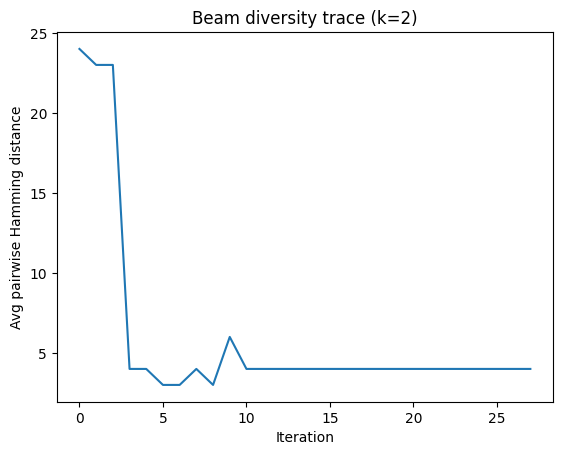

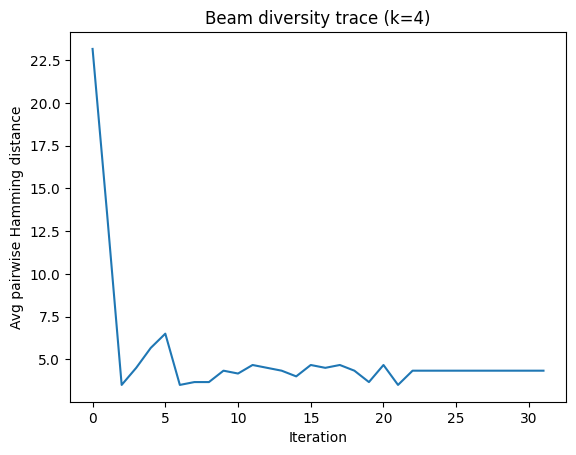

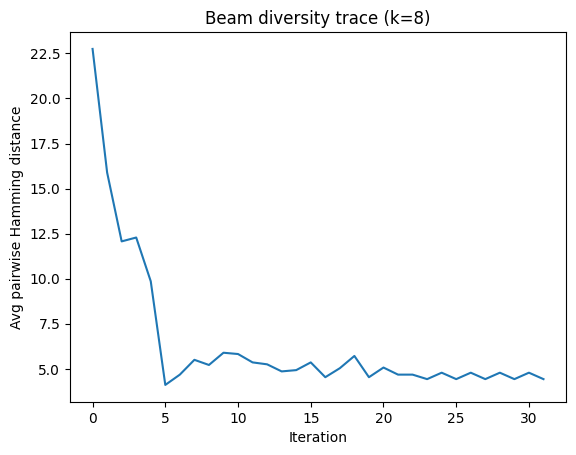

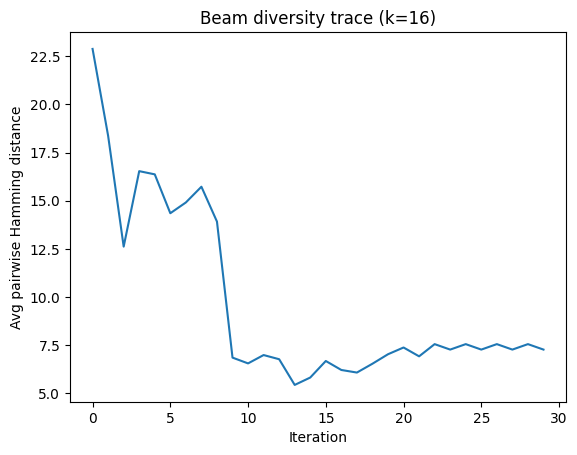

In [7]:
# Plot diversity traces so you can see "beam collapse"
best_k = int(beam_summary.iloc[0]["k"])
print("Best k by cost:", best_k)

for k, trace in diversity_traces.items():
    plot_diversity_trace(trace, title=f"Beam diversity trace (k={k})")

# Part C — The Beam Search Problem (what can go wrong)

Local Beam Search often fails because of **loss of diversity**:

- Even if you keep k routes, after some iterations the best routes can become almost identical.
- Then, exploring neighbors of these nearly identical routes becomes redundant.
- In practice, the algorithm starts to behave like “multiple hill climbers” that all climbed the same hill.

**Evidence you must show:**
- a **diversity trace** that decreases over time, AND
- a **best-cost trace** (or at least the final best cost + plateau behavior via stopping condition).

This motivates Phase 2: using crossover and mutation to re-introduce diversity.

# Part D — Phase 2: Genetic Algorithm with Operator Variants

A Genetic Algorithm (GA) maintains a **population** of routes and repeatedly creates new routes.

Each generation:
1. **Selection:** choose parents that are more likely to be good (lower cost)
2. **Crossover:** combine parts of two parents to make a child route
3. **Mutation:** make a small random change to keep exploration/diversity

---

## Key operators (you must explain in your report)

### OX (Order Crossover)
- Choose two cut points.
- Copy the segment from Parent 1 into the child.
- Fill remaining positions by reading Parent 2 in order and skipping already-used locations.

**Why it works:** it always produces a valid permutation.

### PBX (Position-Based Crossover)
- PBX copies a random set of positions from Parent 1 into the child.
- Then it fills the remaining empty positions by scanning Parent 2 in order, skipping duplicates.

- “Keep these positions from Parent 1, then fill the rest using Parent 2’s order.”
- It always produces a valid permutation (no repeats).

### Swap mutation
Swap two positions in the route.

### Inversion mutation
Reverse a subsequence. Often good for routing because it can remove “crossings”.

### Scramble mutation
Randomly shuffle a subsequence. More disruptive, increases exploration.

---

## Fitness vs cost (beginner note)
We want to **minimize cost**. Many GAs are written to **maximize fitness**.
A common conversion is:

`fitness = 1 / (1 + cost)`

Lower cost → higher fitness → more likely selected.

## Two concrete examples (routes as simple lists)

To make crossover and mutation easier to understand, here are small examples using routes of length 8.

### Example A — OX crossover (Order Crossover)
Parents:
- Parent 1: `[0, 1, 2, 3, 4, 5, 6, 7]`
- Parent 2: `[3, 7, 5, 1, 6, 2, 0, 4]`

Choose cut points `i=2`, `j=5` (copy indices 2..5 from Parent 1):
- Copied segment from Parent 1: `[2, 3, 4, 5]`

Child construction:
1. Start with blanks and place the copied segment:
   - Child: `[_ , _ , 2, 3, 4, 5, _ , _ ]`
2. Scan Parent 2 from left to right and fill the blanks with numbers not already used (`2,3,4,5` are used):
   - Parent 2 order: `3, 7, 5, 1, 6, 2, 0, 4` → keep `7, 1, 6, 0`
3. Fill the remaining blank positions from left to right:
   - Child: `[7, 1, 2, 3, 4, 5, 6, 0]`

### Example B — PBX crossover (Position-Based Crossover)
Parents:
- Parent 1: `[0, 1, 2, 3, 4, 5, 6, 7]`
- Parent 2: `[3, 7, 5, 1, 6, 2, 0, 4]`

Pick a set of positions to copy from Parent 1 (example positions `{1, 4, 6}`):
- Positions 1,4,6 from Parent 1 are values `[1, 4, 6]`

Child construction:
1. Place those values into the child at the same positions:
   - Child: `[_ , 1, _ , _ , 4, _ , 6, _ ]`
2. Fill the remaining empty positions by scanning Parent 2 in order and skipping values already used (`1,4,6`):
   - Parent 2: `3, 7, 5, 1, 6, 2, 0, 4` → keep `3,7,5,2,0`
3. Fill blanks left-to-right:
   - Child: `[3, 1, 7, 5, 4, 2, 6, 0]`

PBX always produces a valid permutation.

### Mutation examples (using the same route)
Start route: `[7, 1, 2, 3, 4, 5, 6, 0]`

- **Swap mutation** (swap positions 1 and 7):  
  → `[7, 0, 2, 3, 4, 5, 6, 1]`

- **Inversion mutation** (reverse slice positions 2..6):  
  slice `[2,3,4,5,6]` becomes `[6,5,4,3,2]`  
  → `[7, 1, 6, 5, 4, 3, 2, 0]`

- **Scramble mutation** (shuffle slice positions 2..6):  
  slice `[2,3,4,5,6]` might become `[4,2,6,3,5]`  
  → `[7, 1, 4, 2, 6, 3, 5, 0]`

In [7]:
def fitness_from_cost(cost: float) -> float:
    """Convert a route cost (to minimize) into a fitness score (to maximize)."""
    return 1.0 / (1.0 + cost)

def is_permutation(route: List[int]) -> bool:
    """Check that route is a valid permutation of 0..m-1."""
    return sorted(route) == list(range(len(route)))

## TODO D1 — Implement crossover operators

The notebook already includes working OX and PBX crossovers below.

Your job is to:
1. Read the code and make sure you understand it.
2. Use them in the GA study in Part E.
3.  Add another permutation crossover if you want (bonus).

In [8]:
def ox_crossover(p1: List[int], p2: List[int], rng: random.Random) -> List[int]:
    """
    OX (Order Crossover) for permutations.

    Steps:
    1) pick cut points i<j
    2) copy p1[i..j] into child
    3) fill remaining slots with p2 in order, skipping duplicates
    """
    n = len(p1)
    i, j = sorted(rng.sample(range(n), 2))
    child = [-1] * n

    child[i:j+1] = p1[i:j+1]
    used = set(child[i:j+1])

    fill_positions = [idx for idx in range(n) if child[idx] == -1]
    fill_values = [x for x in p2 if x not in used]
    for idx, val in zip(fill_positions, fill_values):
        child[idx] = val

    assert is_permutation(child), "OX produced an invalid permutation"
    return child

def pbx_crossover(p1: List[int], p2: List[int], rng: random.Random, keep_frac: float = 0.35) -> List[int]:
    """
    PBX (Position-Based Crossover) for permutations.

    Steps:
    1) randomly select a set of positions (a subset of indices)
    2) copy values from Parent 1 at those positions into the child
    3) fill remaining empty positions by scanning Parent 2 in order, skipping duplicates
    """
    n = len(p1)
    child = [-1] * n

    k = max(1, int(round(keep_frac * n)))
    positions = sorted(rng.sample(range(n), k))

    used = set()
    for idx in positions:
        child[idx] = p1[idx]
        used.add(p1[idx])

    fill_vals = [x for x in p2 if x not in used]
    fill_positions = [i for i in range(n) if child[i] == -1]

    for idx, val in zip(fill_positions, fill_vals):
        child[idx] = val

    assert is_permutation(child), "PBX produced an invalid permutation"
    return child

## TODO D2 — Mutation operators (provided)

Mutation adds randomness so the GA does not become too similar (diversity loss).

You will test:
- swap
- inversion
- scramble

Read the implementations below and use them in Part E.

### Required addition: design a new mutation
Create **one new mutation operator** of your own and test it.

Examples of ideas (you may invent your own):
- **Insert mutation:** remove one city and insert it at another position
- **2-swap + local repair:** do multiple swaps
- **Segment move:** cut a segment and move it elsewhere

Then include your mutation in the Part E study and discuss how it changes performance and stability.

In [11]:
def swap_mutation(r: List[int], rng: random.Random) -> List[int]:
    """Swap mutation: swap two positions."""
    a = r.copy()
    i, j = rng.sample(range(len(a)), 2)
    a[i], a[j] = a[j], a[i]
    assert is_permutation(a)
    return a

def inversion_mutation(r: List[int], rng: random.Random) -> List[int]:
    """Inversion mutation: reverse the route segment between i and j (inclusive)."""
    a = r.copy()
    i, j = sorted(rng.sample(range(len(a)), 2))
    a[i:j+1] = list(reversed(a[i:j+1]))
    assert is_permutation(a)
    return a

def scramble_mutation(r: List[int], rng: random.Random) -> List[int]:
    """Scramble mutation: shuffle the route segment between i and j (inclusive)."""
    a = r.copy()
    i, j = sorted(rng.sample(range(len(a)), 2))
    seg = a[i:j+1]
    rng.shuffle(seg)
    a[i:j+1] = seg
    assert is_permutation(a)
    return a

In [14]:
# ============================================================
# PLACEHOLDER (STUDENT IMPLEMENTS THIS)
# ============================================================
# TODO (STUDENT): Implement ONE new mutation operator of your own.
#
# Requirements:
# - Input: a valid route permutation r (e.g., [7,1,2,3,...])
# - Output: a NEW valid permutation (same elements, no duplicates)
# - You MUST keep the route as a permutation of 0..m-1
# - Keep it reasonably small/change-local (so it acts like a mutation)
#
# After implementing it:
# 1) Keep the assert is_permutation(a)
# 2) Run Part E and compare "custom" to the other mutations.
#
# ============================================================

def your_custom_mutation(r: List[int], rng: random.Random) -> List[int]:
    # plan: swap list[0] & list[7] -> reverse 1,6 -
    a = r.copy() 
    a[0], a[-1] = a[-1], a[0] # Swap two extremes of array
    i, j = (rng.sample(range(len(a)), 2)) # a random swap
    a[i], a[j] = a[j], a[i]
    # TODO (STUDENT): modify 'a' here 
    # The swap here is deterministic and then stochastic
    # Where the change from extremes is known, but the swapping using rng.sample is by randomness
    assert is_permutation(a), "Your mutation must keep a valid permutation"
    return a

## TODO D3 — GA loop (parameterized)

The GA implementation below uses:
- **roulette-wheel selection** (`rng.choices(..., weights=fitness)`)
- **elitism** (copies top `elite` individuals to next generation)
- **early stopping** with `patience`

### Roulette-wheel selection (what it means)
Roulette-wheel selection picks parents **randomly**, but not uniformly:
- each individual gets a “slice of the wheel” proportional to its **fitness**
- higher fitness → larger slice → higher chance to be selected

In this notebook, fitness is `1/(1+cost)`, so lower-cost routes are more likely to be chosen.

### Required modification (selection comparison)
Add **tournament selection** to the GA and compare it to roulette-wheel selection.

Tournament selection works like this:
1. randomly sample `t` individuals from the population (e.g., `t=3`)
2. choose the **best** (lowest cost) among them as a parent
3. repeat to select the second parent

Then run the Part E study using:
- roulette-wheel selection
- tournament selection (your added option)

and compare results (mean cost, std, runtime, evaluations).

In [18]:
# ============================================================
# PLACEHOLDER (STUDENT IMPLEMENTS THIS)
# ============================================================
# TODO (STUDENT): Implement tournament selection.
#
# Tournament selection (size t):
# 1) randomly sample t individuals from the population
# 2) return the individual with the LOWEST cost among those sampled
#
# Requirements:
# - Must return one route (a permutation) from 'pop'
# - Should use rng (not random.random directly) for reproducibility
# ============================================================

def tournament_select(pop: List[List[int]], costs: List[float], rng: random.Random, t: int = 3) -> List[int]:
    # TODO (STUDENT): implement tournament selection
    # My notes:
    # 1. randomly sample t from pop
    # 2. return the individual with lowest cost
    # 3. returns one route, must use rng
    # using the example value provided t is already = 3
    index = rng.sample(range(len(pop)), t) # random, unordered
    # now return the lowest cost from index
    lowest_cost = min(index, key = lambda i: costs[i]) 
    return pop[lowest_cost] # grabbing lowest cost from pop
    # raise NotImplementedError("STUDENT TODO: implement tournament_select")

In [19]:
# ============================================================
# Genetic Algorithm (provided reference implementation)
# ============================================================
# You are NOT asked to implement the full GA from scratch.
# This implementation is provided so you can focus on:
# - implementing tournament selection (TODO placeholder above),
# - implementing a custom mutation (TODO placeholder),
# - running controlled experiments and interpreting results.
# ============================================================

from dataclasses import dataclass

@dataclass
class GAResult:
    best_route: List[int]
    best_cost: float
    gens: int
    evaluated: int
    runtime_s: float

def fitness_from_cost(cost: float) -> float:
    """Convert a route cost into a positive fitness weight (higher = better)."""
    return 1.0 / (1.0 + float(cost))

def genetic_algorithm(
    M: np.ndarray,
    m: int,
    pop_size: int = 80,
    max_gens: int = 600,
    pm: float = 0.08,
    elite: int = 2,
    patience: int = 80,
    crossover_fn: Callable[[List[int], List[int], random.Random], List[int]] = ox_crossover,
    mutation_fn: Callable[[List[int], random.Random], List[int]] = swap_mutation,
    seed: int = 0,
    selection: str = "roulette",   # "roulette" or "tournament"
    tournament_size: int = 3
) -> GAResult:
    """
    Genetic Algorithm for routing (permutation representation).

    Parameters
    ----------
    M : cost matrix (includes depot row/col at index 0)
    m : number of delivery locations (not counting depot)
    selection : "roulette" or "tournament"
        - roulette: choose parents randomly with probability proportional to fitness
        - tournament: choose parents via tournament_select(pop, costs, rng, t=...)
          (NOTE: tournament_select is a STUDENT TODO placeholder above.)
    """
    rng = random.Random(seed)
    t0 = time.time()

    # 1) Initialize a population of random routes (permutations of 0..m-1)
    pop = [random_route(m, rng) for _ in range(pop_size)]
    evaluated = 0

    best_route = pop[0]
    best_cost = float("inf")
    no_improve = 0

    for gen in range(max_gens):
        # 2) Evaluate population
        costs = [route_cost(ind, M) for ind in pop]
        evaluated += len(pop)

        # Sort population by cost (best first)
        order = sorted(range(pop_size), key=lambda i: costs[i])
        pop = [pop[i] for i in order]
        costs = [costs[i] for i in order]

        # Track best
        if costs[0] + 1e-9 < best_cost:
            best_cost = costs[0]
            best_route = pop[0]
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        # 3) Build next generation
        new_pop = pop[:elite]  # elitism: keep top routes unchanged

        if selection.lower() == "roulette":
            fitness = [fitness_from_cost(c) for c in costs]

        while len(new_pop) < pop_size:
            # --- parent selection ---
            if selection.lower() == "roulette":
                p1, p2 = rng.choices(pop, weights=fitness, k=2)
            elif selection.lower() == "tournament":
                # tournament_select is intentionally left as a STUDENT TODO placeholder
                p1 = tournament_select(pop, costs, rng, t=tournament_size)
                p2 = tournament_select(pop, costs, rng, t=tournament_size)
            else:
                raise ValueError("selection must be 'roulette' or 'tournament'")

            # --- crossover ---
            child = crossover_fn(p1, p2, rng)

            # --- mutation (probability pm) ---
            if rng.random() < pm:
                child = mutation_fn(child, rng)

            new_pop.append(child)

        pop = new_pop

    return GAResult(
        best_route=best_route,
        best_cost=best_cost,
        gens=gen + 1,
        evaluated=evaluated,
        runtime_s=time.time() - t0
    )

# Part E — Required Study: GA Variations vs Beam Search

This section provides a precise, repeatable experiment plan so your results are fair and comparable.

---

## Step 1 — Baseline Beam Search (required)

**Goal:** Establish a strong beam-search baseline and collect evidence of beam collapse.

1. **Fix one problem instance**
   - Choose `instance_seed` (example: 11).
   - Generate the instance once and keep it the same for all runs so every method is solving the exact same map.

2. **Choose algorithm seeds**
   - Use `algo_seeds = range(10)` for the report.
   - Each seed changes random initial routes, so each run is slightly different.

3. **Run 3 beam widths**
   - Run beam search with `k ∈ {4, 8, 16}` for every seed.
   - Record for each run: `best_cost`, `evaluated`, `runtime_ms`.

4. **Document the failure mode**
   - For at least one k (ideally the best k), plot the **diversity trace**.
   - Also report the best cost and show that the algorithm stops because it stopped improving (`patience` reached), which indicates a plateau.

**What to include in your write-up:**
- a table of mean ± std best_cost for Beam(k=4), Beam(k=8), Beam(k=16)
- at least one diversity plot that decreases over iterations (collapse)

---

## Step 2 — GA to resolve the issue (required)

**Goal:** Show that GA’s crossover+mutation maintains diversity and can improve on the beam baseline.

1. **Use the same instance**
   - Do not change `instance_seed`.

2. **Use the same set of algorithm seeds**
   - Use the same `algo_seeds` so the number of runs matches beam search.

3. **Choose a fair compute budget**
   - In this notebook, the GA budget is controlled by:
     - `pop_size` (population size)
     - `max_gens` (maximum generations)
     - early stopping (`patience`)
   - Report `evaluated` as the fair, comparable compute metric.

4. **Compare against the best beam baseline**
   - Compare **mean cost**, **std cost**, and **best seen**.
   - Discuss the tradeoff between solution quality and compute (evaluations/runtime).

---

## Step 3 — Operator Variant Study (required)

For each combination:
- crossover ∈ {OX, PBX}
- mutation ∈ {swap, inversion, scramble}
- mutation rate pm ∈ {0.02, 0.08}

Run **10 seeds** and compute:
- mean(best_cost), std(best_cost)
- mean(runtime_ms)
- mean(evaluated)

## How `run_study()` works (read this before running it)

`run_study()` is the main experiment driver. It automates the required comparisons so you do not have to run dozens of configurations by hand.

What it does, step-by-step:

1. **Creates one fixed problem instance**
   - It calls `make_clustered_instance(M=M_locs, clusters=clusters, seed=instance_seed)`.
   - Because `instance_seed` is fixed, every algorithm is tested on the **same** set of locations.

2. **Runs the Beam Search baseline**
   - For each `seed` in `algo_seeds`, it runs beam search with `k ∈ {4, 8, 16}`.
   - Each run records `best_cost`, `evaluated`, and `runtime_ms`.

3. **Runs the GA grid**
   - For each `seed` in `algo_seeds`, it runs GA for:
     - selection method ∈ {roulette, tournament}
     - crossover ∈ {OX, PBX}
     - mutation ∈ {swap, inversion, scramble, custom}
     - mutation rate `pm` ∈ {0.02, 0.08}
   - Each run records the same metrics as beam search.

4. **Returns one table**
   - The output is a DataFrame where each row is one run (one seed × one method setting).

### How the Required minimum is satisfied by the code

- **At least 10 seeds per configuration:** set `algo_seeds = range(10)` when you run `run_study()` for the final report.
- **At least one clustered instance:** `make_clustered_instance(...)` generates a clustered instance every time.
- **Required comparisons are included:** the dictionaries `crossovers`, `mutations`, `mutation_rates`, and `selections` explicitly list the required options.

You may run fewer seeds temporarily to test your code, but the report must use `range(10)`.

In [20]:
def run_study(instance_seed=11, algo_seeds=range(10), M_locs=20, clusters=3):
    """
    Run the REQUIRED experiment suite on ONE instance.

    instance_seed: controls the generated map (same seed => same locations)
    algo_seeds: controls algorithm randomness (different seeds => different runs)
    M_locs: number of delivery locations (keep ~18-20 if runtime is high)
    """
    depot, locs = make_clustered_instance(M=M_locs, clusters=clusters, seed=instance_seed)
    Mmat = cost_matrix(depot, locs)
    m = len(locs)

    rows = []

    # ----------------------------
    # Beam baselines (required)
    # ----------------------------
    for s in algo_seeds:
        for k in [4, 8, 16]:
            br = local_beam_search(Mmat, m, k=k, max_iters=250, patience=30, seed=s)
            rows.append({
                "seed": s,
                "method": f"Beam(k={k})",
                "best_cost": br.best_cost,
                "evaluated": br.evaluated,
                "iters/gens": br.iters,
                "runtime_ms": 1000 * br.runtime_s
            })

    # ----------------------------
    # GA variants (required)
    # ----------------------------
    crossovers = {"OX": ox_crossover, "PBX": pbx_crossover}
    mutations = {"swap": swap_mutation, "inversion": inversion_mutation, "scramble": scramble_mutation}
    mutation_rates = [0.02, 0.08]

    # Required: compare roulette-wheel vs tournament selection
    selections = [("roulette", "roulette"), ("tournament", "tournament")]

    for s in algo_seeds:
        for sel_label, sel in selections:
            for cx_name, cx in crossovers.items():
                for mut_name, mut in mutations.items():
                    for pm in mutation_rates:
                        gr = genetic_algorithm(
                            M=Mmat, m=m,
                            pop_size=80, max_gens=600, pm=pm,
                            elite=2, patience=80,
                            crossover_fn=cx, mutation_fn=mut,
                            seed=s,
                            selection=sel,
                            tournament_size=3
                        )
                        rows.append({
                            "seed": s,
                            "method": f"GA[{sel_label}]({cx_name},{mut_name},pm={pm})",
                            "best_cost": gr.best_cost,
                            "evaluated": gr.evaluated,
                            "iters/gens": gr.gens,
                            "runtime_ms": 1000 * gr.runtime_s
                        })

    return pd.DataFrame(rows)

# SAMPLE RUN (fast preview)
df = run_study(instance_seed=11, algo_seeds=range(5), M_locs=18, clusters=3)

(df.groupby("method")[["best_cost", "runtime_ms", "evaluated"]]
   .mean()
   .sort_values("best_cost")
   .head(12))

,best_cost,runtime_ms,evaluated
method,,,
"GA[tournament](OX,inversion,pm=0.08)",27.462407,240.499353,14384.0
"GA[roulette](OX,inversion,pm=0.08)",27.555413,239.143753,17024.0
"GA[roulette](OX,inversion,pm=0.02)",28.022776,278.703737,20768.0
"GA[tournament](OX,inversion,pm=0.02)",28.175260,239.000893,14576.0
"GA[tournament](PBX,inversion,pm=0.08)",28.448177,274.657154,14928.0
"GA[roulette](OX,swap,pm=0.02)",28.574046,277.001619,20512.0
"GA[tournament](PBX,inversion,pm=0.02)",28.598253,338.997316,18368.0
Beam(k=16),28.746415,473.623037,107712.0
"GA[roulette](OX,scramble,pm=0.08)",28.749014,248.893213,17648.0


## TODO E1 — Summarize results (required)

Compute, for each method:

- **mean(best_cost)** and **std(best_cost)** across seeds
- **mean(runtime_ms)** across seeds
- **mean(evaluated)** across seeds

Then answer:
1. Best-performing GA variant(s) by **lowest mean cost**.
The best performing GA variant by lowest mean cost is `GA[tournament](OX, inversion, pm = 0.08)` at 27.46 cost and `GA[roulette](OX,inversion,pm=0.08)`following it at 27.56 cost. 
2. Most stable GA variant(s) by **lowest std cost**.
The most stable GA variant by lowest std cost was `GA[tournament](OX, inversion, pm = 0.08)` at a 0.0 `std_cost`. The next most stable was `GA[roulette](OX,inversion,pm=0.08)` at 0.21 std_cost.
3. Compare the best GA variant to the best beam setting.
The best GA variant was `GA[tournament](OX, inversion, pm = 0.08)` at 27.46 cost whereas the best beam setting was k = 16 at 28.75. Although not seemingly far apart, one may note that the best GA variant only had a 14384 mean_evaluated paths, whereas the k=16 beam had 107712, more than 7 times as much as the GA variant. This indicates that a GA is far less compute heavy and perhaps more efficient. Additionally, the GA had a runtime of 240.5 ms whereas the k=16 beam had 473.6, confirming the higher compute argument needed in beam search. Finally, the GA was perfectly stable with a 0 std_cost compared to k=16 beam at 1.17. Clearly the GA is more reliable, less compute heavy, and is the cheapest.

### What does std mean?
- **std (standard deviation)** tells you how much results vary across random seeds.
- Lower std → more consistent performance.

In [24]:
# Summary table across seeds (this is what you should include in your report)
summary = (
    df.groupby("method")
      .agg(
          runs=("best_cost", "count"),
          mean_cost=("best_cost", "mean"),
          std_cost=("best_cost", "std"),
          best_seen=("best_cost", "min"),
          mean_runtime_ms=("runtime_ms", "mean"),
          mean_evaluated=("evaluated", "mean"),
      )
      .sort_values("mean_cost")
)

summary.head(20)

,runs,mean_cost,std_cost,best_seen,mean_runtime_ms,mean_evaluated
method,,,,,,
"GA[tournament](OX,inversion,pm=0.08)",5,27.462407,0.000000,27.462407,240.499353,14384.0
"GA[roulette](OX,inversion,pm=0.08)",5,27.555413,0.207969,27.462407,239.143753,17024.0
"GA[roulette](OX,inversion,pm=0.02)",5,28.022776,0.643608,27.462407,278.703737,20768.0
"GA[tournament](OX,inversion,pm=0.02)",5,28.175260,0.690996,27.462407,239.000893,14576.0
"GA[tournament](PBX,inversion,pm=0.08)",5,28.448177,1.373645,27.462407,274.657154,14928.0
"GA[roulette](OX,swap,pm=0.02)",5,28.574046,1.322484,27.562241,277.001619,20512.0
"GA[tournament](PBX,inversion,pm=0.02)",5,28.598253,0.793844,27.562496,338.997316,18368.0
Beam(k=16),5,28.746415,1.173457,27.462407,473.623037,107712.0
"GA[roulette](OX,scramble,pm=0.08)",5,28.749014,1.455328,27.462407,248.893213,17648.0


In [22]:
# Quick interpretation helpers (optional but beginner-friendly)
best_method = summary.index[0]
print("Best method by mean cost:", best_method)
print(summary.loc[best_method])

# Compare best GA vs best Beam
best_beam = summary.loc[[m for m in summary.index if m.startswith("Beam")]].sort_values("mean_cost").head(1)
best_ga = summary.loc[[m for m in summary.index if m.startswith("GA(")]].sort_values("mean_cost").head(1)

print("\nBest Beam setting:")
display(best_beam)

print("\nBest GA variant:")
display(best_ga)

Best method by mean cost: GA[tournament](OX,inversion,pm=0.08)
runs                   5.000000
mean_cost             27.462407
std_cost               0.000000
best_seen             27.462407
mean_runtime_ms      240.499353
mean_evaluated     14384.000000
Name: GA[tournament](OX,inversion,pm=0.08), dtype: float64

Best Beam setting:


,runs,mean_cost,std_cost,best_seen,mean_runtime_ms,mean_evaluated
method,,,,,,
Beam(k=16),5,28.746415,1.173457,27.462407,473.623037,107712.0



Best GA variant:


,runs,mean_cost,std_cost,best_seen,mean_runtime_ms,mean_evaluated
method,,,,,,


# Report Questions (short answers)

Write short, clear answers in your own words (bullet points are OK).

1. **Beam Search first:** Which `k` gave the best mean result?  
   Show evidence of plateau and beam collapse using the diversity trace plot. 
* The 'k' that gave the best mean result was k=16. The graphs (found under cell 6) demonstrate evidence of plateau approaching and beam collapse. 
* At k=16 beam collapse started at iteration 3 and continued to 7, eventually turning into a repeated hill-climber causing the program to lose its patience and end. The diversity trace plot for k=2, 4, 8 on the other hand, show much steeper hamming distance decreases almost immediately and even before reaching 5 iterations.
2. **The problem:** Why does loss of diversity make beam search behave like multiple hill climbers?
* Loss of diversity creates a multiple hill climber effect because nodes are limited by proximity, similar to hill climbing.
* If a nodes hamming distance is low it will try to reach the nearest node neighboring it, limited to its beam width, similar to how a hill-climber searches only for its greatest neighbor.
* We see this clearly with `k=2` plot (found under cell 6), where the small beam width causes immediate low diversity, and due to this the algorithm struggles to find new solutions and stays in a plateau state.
3. **GA as a fix:** Which GA variant beat beam search most reliably (lowest mean cost and/or lowest std), and why do crossover + mutation help escape local optima?
* The GA variant that beat beam search was `GA[tournament](OX, inversion, pm = 0.08)`. Most reliably with a standard deviation of 0.0 and mean cost of 27.462407 compared to the beam search `k = 16` standard deviation of 1.173 and higher `mean_cost` 28.75 (according to the table of cell 24:).
* Crossover avoids encountering a local optima by mixing parents with each other thus making them diverse, contrasting beam search or hill climbing, which only observes by proximity without mixing. This crossover inherently swaps genes of one to another, naturally influencing diversity. 
* Mutation provides a sense of randomness via a function to the offspring and thus makes nodes less likely to be similar to one another, avoiding local optima peaking. 
4. **Crossover study:** OX vs PBX—what patterns might each preserve in a route, and which worked better in your experiments?
* In Order Crossover, the patterns that might preserve in each route are the order of the integers to be crossed with another parent. More specifically, this refers to the relative order of one parent's groups being preserved when combined with another parent. Example: Parent 1: `[0,1,2,3,4,5,6,7]`, we may preserve the group order of `[2,3,4,5]`. ref. above cell 7, Example A explanation.
* In Position Based Crossover, what might be preserved is the indices of the integers used. More specifically, the entire index structure of one parent will remain with the same values preserved. 
* Between OX and PBX, OX performed the best most frequently. The table on cell :24 supports this claim by showing the top 1-4 and 6th methods as those with OX: `GA[tournament](OX,inversion,pm=0.08)` to `GA[roulette](OX,swap,pm=0.02)` occupying 5/6 first methods ranked by `mean_cost` = 27.46 to 28.57.	
* This is likely because OX exploits proximity by maintaining order thus causing less disruption. In contrast PBX experiences more disruption thus being more likely to destroy good structures.
5. **Mutation study:** swap vs inversion vs scramble—how did each affect exploration and convergence?

*According to Part C Mutation Examples and Table Under Cell 24:*
* Swap: Swap mutation is responsible for swapping two values' indices.
* Inversion: Inversion mutation refers to flipping the indices of values to their inverses respective to the center of the array.
* Scramble: Scramble mutation shuffles the positions of the values.
*How did they affected exploration and convergence*
* After self-calculating the mean of the top 4 mean_evaluated for each `inversion`, `swap` and `scramble` methods, I concluded that `inversion` and `swap` had the lowest exploration, with `inversion`'s top 4 mean of mean_evaluated at 16688 and `swap`'s at 16932, slightly more, and `scramble` reaching the highest on average of their `mean_evaluated` at 18472. The higher the value, the more paths explored, later convergence, perhaps suggesting better solutions.
* However, `Inversion` demonstrated more lower `mean_cost` on average than the other mutations, thus showing that although paths evaluated may be low and converging earlier than `scramble` for example, `inversion` may be the best mutation method given cost is a concern. Higher evaluation values suggest later convergence and thus more costly though sometimes better solutions. 
* Regarding convergence `inveersion` and `swap` converged much earlier 
6. **Mutation rate:** Compare `pm=0.02` and `pm=0.08`; which was better and why?
* `pm=0.08` generally performed better than `pm=0.02`.
* `pm=0.08` is seen to perform better when comparing similar methods only varying by their mutation probability, e.g.: `GA[Tournament](OX,Inversion,pm=0.08)` was a better `mean_cost` (at 27.46) and lower `std_cost` (at 0.0) than its counter part at `pm=0.02` (`mean_cost` = 28.18, `std_cost` = 0.69) and so fourth for other methods analogous. For exact metrics, see table under cell 24.
* The reason `pm=0.08` performed better is because a higher mutation probability increases the chances of a mutation and a mutation promotes a more diverse set of children and thus more likely to continue with the algorithm at a lower cost needed.
7. **Computational cost:** Which method required more evaluations, and was the extra cost worth it?
* The method that required the most evaluations was method `k = 16` of beam search at 107712 `mean_evaluated` (according to table cell 24:).
* The extra cost was not worth it because although it was more compute-heavy, it did not achieve better cost scores generally when compared to the best GAs. There were 7 GAs that achieved better costs with evaluations with even 7 times less iterations and better variability (first achieving 0.0 `std_cost`). 
8. **Selection method comparison:** Roulette-wheel vs tournament selection—what differences did you see, and which worked better on this instance?
* Typically, tournament method performs better that selection. This is because tournament selects winners in a given subset, whereas selection works only on a fitness function that may select an individual multiple times thus subject to converging early.
* Looking only at the mean_cost in the table under cell 24, we may notice that the best cost (27.46) was from a tournament, suggesting tournaments can find the best solutions most efficiently.
* Observing the `mean_evaluated`, we also see tournament exploring less paths compared to the two subsequent roulettes below it. First Inversion at 14384 and first Roulette at 17024 and second 20768, suggesting potential increases in paths necessary as `mean_cost` increases. Although less paths suggest worse solutions, tournament was ultimately the best option because it provided the cheapest and most optimal solution despite converging earlier.
9. **Custom mutation:** Describe your mutation, why you designed it, and what effect it had on results.
* My mutation swapped the two extremes of the array ([0] & [-1])
* It then randomly selected two indices to swap via `rng.`
* I designed the mutation this way so that the algorithm experiences mutations, but not such that it can disrupt. So I limited it to two methods of swapping. The swaps I selected fall into two categories: a deterministic mutation (always swapping extreme indices) and a stochastic mutation (via `rng` swap). These ensure a balance between diversity and disruption are met for the results, allowing results to have good-sized evaluated paths while also maintaining good cost.

# Grading rubric (Total = 100 points)

Your notebook will be graded using the point breakdown below. Your submitted `.ipynb` must already contain **all outputs** (tables, plots, and written answers).

## A) Correct implementation (35 points)
- **Tournament selection implementation (TODO)** — **20**
  - Correct tournament logic; integrates into GA runs; selection toggle works.
- **Custom mutation implementation (TODO)** — **15**
  - Always returns a valid permutation; included in the study grid; runs without errors.

## B) Required experiments and outputs present (15 points)
- **Beam Search baseline runs present** (`k = 4, 8, 16` across **10 seeds**) — **5**
  - Summary table rows exist for all three beam settings.
- **GA grid runs present** (**10 seeds**) for both **roulette** and **tournament** selection — **5**
  - Includes OX and PBX crossovers; includes swap/inversion/scramble/custom mutations; includes `pm ∈ {0.02, 0.08}`.
- **Evidence plots present** — **5**
  - Diversity trace(s) for beam search are shown in the notebook output.

## C) Research questions (Report Questions) (50 points)

Answer each question using evidence from your tables/plots. Points are allocated per question:

1. **Beam Search first:** Which `k` gave the best mean result? Show plateau and beam collapse evidence. — **8**
2. **The problem:** Explain why loss of diversity makes beam search behave like multiple hill climbers. — **6**
3. **GA as a fix:** Which GA variant beat beam search most reliably (mean/std) and why crossover+mutation help. — **8**
4. **Crossover study:** OX vs PBX—what patterns might each preserve, and which worked better in your results. — **5**
5. **Mutation study:** swap vs inversion vs scramble—how did each affect exploration and convergence. — **5**
6. **Mutation rate:** Compare `pm=0.02` vs `pm=0.08`; which was better and why. — **4**
7. **Computational cost:** Compare evaluations/runtime across methods; was extra compute worth it. — **4**
8. **Selection method comparison:** Roulette-wheel vs tournament selection—what differences did you see and why. — **5**
9. **Custom mutation:** Describe your mutation and its measured effect in the study. — **5**

### Note on evidence
For full credit, when you make a claim, point to a specific table row/metric (mean/std/best_seen/runtime/evaluated) or a plot and explain what it shows.